In [11]:
%load_ext autoreload
%autoreload 2

import numpy as np
from asrl.ogmapping.og_map import OccupancyGridMapper
import matplotlib.pyplot as plt
from time import perf_counter
from spatialmath import SE2, SO2
import scipy

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
from asrl.slam_sim.array_map import ArrayMap

env = ArrayMap('/home/dev/workspace/asrl/maps/floorplan1.txt', resolution=1, verbose=True)
height, width = env._walls.shape

og_map = OccupancyGridMapper(0.2, width, height,
                             p_hit=0.9, p_miss=0.2,
                            #  max_height_px=24,
                            #  max_width_px=24
                             )

Walls shape: (15, 20), Free space shape: (15, 20)
[[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1]
 [1 0 0 0 0 0 0 1 0 1 1 1 1 0 0 1 0 0 0 1]
 [1 0 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 0 0 1]
 [1 1 0 0 0 1 1 1 0 1 0 0 1 1 1 1 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1]
 [1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1]
 [1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1]
 [1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1]
 [1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1]
 [1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]]


In [8]:
# visited_cells_ij = np.random.choice(env._free_space_indices_ij.shape[0], size=30, replace=False)
scan_positions_xy_m = env._indexer.ij_to_xy_m(env._free_space_indices_ij)
n_poses = scan_positions_xy_m.shape[0]

poses = np.zeros((n_poses, 3))
poses[:, :2] = scan_positions_xy_m
poses[:, 2] = np.random.uniform(0, 2 * np.pi, n_poses)

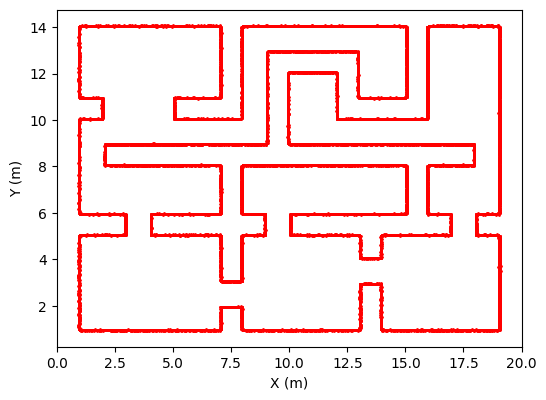

In [9]:
scans = env.raycast_in_map(poses, range_noise_m=0.01)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

for i in range(n_poses):
    pose = SE2(poses[i])
    scan_b_B = scans[i]
    scan_w_W = pose * scan_b_B.T
        
    ax.scatter(scan_w_W[0, :], scan_w_W[1, :], c='red', s=1)

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_aspect('equal')
plt.show()

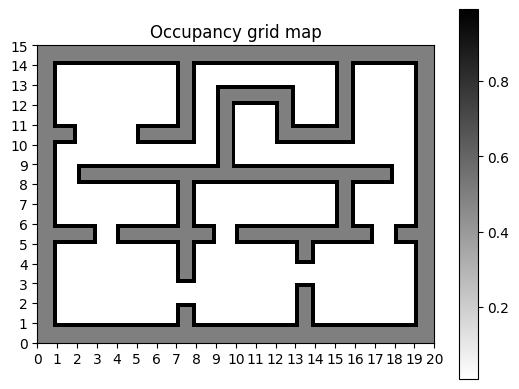

In [10]:
og_map.reset()

for i in range(n_poses):
    og_map.process_scan(poses[i], scans[i])
    
grid_prob = og_map.to_prob_map()

res = og_map._indexer.resolution
width_cells = og_map.grid.shape[1]
height_cells = og_map.grid.shape[0]
extent = [0, width_cells * res, 0, height_cells * res]

plt.figure()
plt.imshow(grid_prob, 
           cmap='gray_r', interpolation='nearest',
           origin='upper', extent=extent)

xticks = np.arange(0, width_cells * res + 0.1, 1.0)
yticks = np.arange(0, height_cells * res + 0.1, 1.0)
plt.xticks(xticks)
plt.yticks(yticks)

# plt.grid(which='both', color='white', linestyle='--', linewidth=0.5)
plt.colorbar()
plt.title('Occupancy grid map')
plt.savefig("retarded.png")
plt.show()

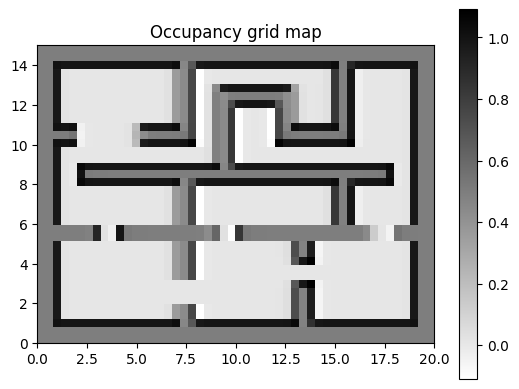

In [14]:
scaled_grid_prob = scipy.ndimage.zoom(grid_prob, zoom=(0.5, 0.5))

# res = og_map._indexer.resolution
# width_cells = og_map.grid.shape[1]
# height_cells = og_map.grid.shape[0]
# extent = [0, width_cells * res, 0, height_cells * res]

plt.figure()
plt.imshow(scaled_grid_prob, 
           cmap='gray_r', interpolation='nearest',
           origin='upper', extent=extent)

# xticks = np.arange(0, width_cells * res + 0.1, 1.0)
# yticks = np.arange(0, height_cells * res + 0.1, 1.0)
# plt.xticks(xticks)
# plt.yticks(yticks)

# plt.grid(which='both', color='white', linestyle='--', linewidth=0.5)
plt.colorbar()
plt.title('Occupancy grid map')
plt.show()

In [19]:
from scipy.sparse import csr_array
from scipy.sparse.csgraph import shortest_path, dijkstra

In [22]:
graph = [
[0, 1, 2, 0],
[0, 0, 0, 1],
[0, 0, 0, 3],
[0, 0, 0, 0]
]
graph = csr_array(graph)
print(graph)

<Compressed Sparse Row sparse array of dtype 'int64'
	with 4 stored elements and shape (4, 4)>
  Coords	Values
  (0, 1)	1
  (0, 2)	2
  (1, 3)	1
  (2, 3)	3


In [23]:
dist_matrix, predecessors = dijkstra(csgraph=graph, directed=False, indices=0, return_predecessors=True)
print(predecessors)

[-9999     0     0     1]
